## Implied Volatility in Lifted Heston model 

See full explanation and results in corresponding [doc](../docs/lifted_heston_iv.md)

### 1 - Lifted Heston Functions

In [ ]:
import math
import warnings
import numpy as np
from tqdm import tqdm
from scipy import linalg
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Return F(u,v)
def F(u,v,lamb,nu,rho):
    return 0.5*(u**2-u)+(rho*nu*u-lamb)*v+0.5*nu**2*v**2

# Returns the means reversions x_i
def x(alpha, rn, i, n):
    return ((1 - alpha) * (rn**(2 - alpha) - 1)) / ((2 - alpha) * (rn**(1 - alpha) - 1)) * rn**(i - 1 - n / 2)

# Returns the weights c_i
def c(alpha, rn, i, n):
    return ((rn**(1 - alpha) - 1) / (math.gamma(alpha) * math.gamma(2 - alpha))) * rn**((1 - alpha) * (i - 1 - n / 2))

# Returns the initial curve g0(t)
def g0(t, V0, lamb, theta, alpha, rn, n):
    inter = 0
    for i in range(1,n+1):
        inter = inter + c(alpha,rn,i,n)*quad(lambda s: np.exp(-x(alpha,rn,i,n)*(t-s)),0,t)[0]
    return V0 + lamb*theta*inter

# Return the approximation of the characteristic function in the Lifted Heston model
def Ch_Lifted_Heston(u,S0,T,rho,lamb,theta,nu,V0,n,rn,alpha,M):
    dt = T/M
    psi = np.zeros((M,n), dtype=complex)
    grid = np.linspace(0,T,M)

    xi = np.array([x(alpha, rn, i, n) for i in range(1, n+1)])
    ci = np.array([c(alpha, rn, i, n) for i in range(1, n+1)])

    # Calculation of psi
    for k in range(1, M):
        cpsi = np.dot(ci, psi[k-1])
        psi[k] = (psi[k-1] + F(1j*u, cpsi, lamb, nu, rho) * dt) / (1 + xi * dt)

    # Trapezoidal rule to estimate the integral
    integrand = np.array([
        g0(T - t, V0, lamb, theta, alpha, rn, n) * F(1j*u, np.dot(ci, psi[k]), lamb, nu, rho)
        for k, t in enumerate(grid)
    ])
    approx = np.trapz(integrand, grid)

    return np.exp(1j * u * np.log(S0) + approx)


### 2 - Options Pricing and Implied Volatility 

In [11]:
# Return the approximation of a call option price in the Lifted Heston model according to the Carr-Madan formula in Q2
def Call_Price_Lifted_Heston(S0, K, T, rho, lamb, theta, nu, V0, n, rn, alpha, M, alpha2, L):
    inte = lambda u: (np.exp(-1j * u * np.log(K)) *Ch_Lifted_Heston(u - (alpha2 + 1)*1j,S0,T,rho,lamb,theta,nu,V0,n,rn,alpha,M)/((alpha2 + 1j * u) * (alpha2 + 1 + 1j * u))).real
    integral = quad(inte,0,L)[0]
    call_price = (np.exp(-alpha2 * np.log(K)) / np.pi) * integral
    return call_price

# Black-Scholes Call Price
def bs_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Implied Volatility using Brent's method
def implied_vol(S0, K, T, r_int, call_price):
    
    # Function to find the root 
    def difference_in_prices(sigma):
        return bs_call(S0, K, T, r_int, sigma) - call_price

    return brentq(difference_in_prices, a=1e-6, b=2.5, xtol=1e-6)


### 3 - Implied Vol Lifted Heston Long Term

Functions

In [12]:
# Returns Implied Volatility under Lifted Heston model and params
def compute_res(params):
    impl_vol = np.zeros((len(params["n"]),len(params["K"])))

    # Return and plot the implied volatility according the given parameters
    for i in tqdm(range(len(params["n"])), desc='EXT', leave=False):
        for j in tqdm(range(len(params["K"])), desc='INT', leave=False):
            rn = (1+10*params["n"][i]**(-0.9))
            
            C0 = Call_Price_Lifted_Heston(
                S0 = params["S0"], K = params["K"][j], T = params["T"], rho = params["rho"], 
                lamb = params["lambda"], theta = params["theta"], nu = params["nu"], 
                V0 = params["V0"], n = params["n"][i], rn = rn, alpha = params["alpha"], 
                M = params["M"], alpha2 = params["alpha2"], L = params["L"]
            )
            
            impl_vol[i,j] = implied_vol(
                S0 = params["S0"], K = params["K"][j], T = params["T"], 
                r_int = 0, call_price = C0
            )
    return impl_vol

Input:

In [13]:
params = {
    "K": np.exp(np.linspace(-1.2, 0.2, 20)), # Strikes
    "n": [5,10,20,50], # n factors
    "S0": 1,
    "T": 1,
    "rho": -0.7,
    "lambda": 0.3,
    "theta": 0.02,
    "nu": 0.3,
    "V0": 0.02,
    "alpha": 0.6,
    "M": 100,
    "alpha2": 1,
    "L": 100
}

Computation and output:

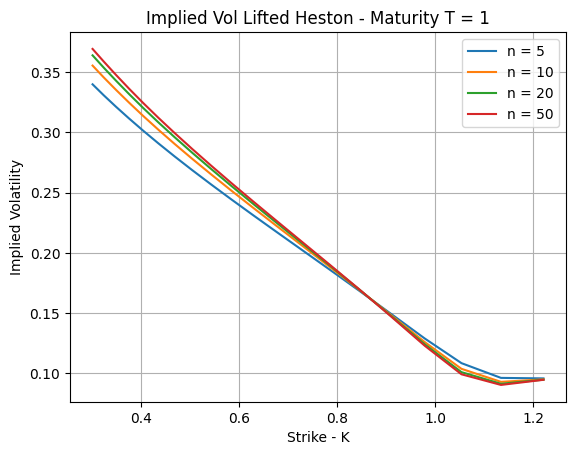

In [14]:
impl_vol_lt = compute_res(params)
        
for i in range(len(params["n"])):
    plt.plot(params["K"], impl_vol_lt[i,:], label='n = {}'.format(params["n"][i]))

plt.title('Implied Vol Lifted Heston - Maturity T = 1')
plt.grid(True)
plt.xlabel('Strike - K')
plt.ylabel('Implied Volatility')
plt.legend()
plt.show()


### 4 - Implied Vol Lifted Heston Short Term

Input:

In [15]:
params1 = {
    "K": np.exp(np.linspace(-0.15, 0.05, 20)), # Strikes
    "n": [5,10,20,50], # n factors
    "S0": 1,
    "T": 1/26,
    "rho": -0.7,
    "lambda": 0.3,
    "theta": 0.02,
    "nu": 0.3,
    "V0": 0.02,
    "alpha": 0.6,
    "M": 100,
    "alpha2": 1,
    "L": 1000
}

Computation and output:

EXT:   0%|          | 0/4 [00:00<?, ?it/s]

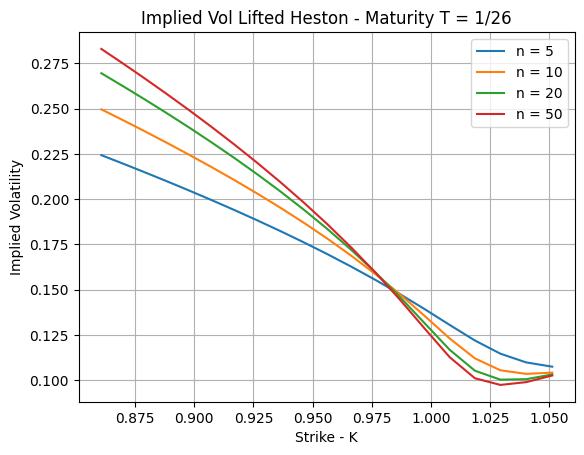

In [16]:
impl_vol_st = compute_res(params1)
        
for i in range(len(params1["n"])):
    plt.plot(params1["K"], impl_vol_st[i,:], label='n = {}'.format(params1["n"][i]))

plt.title('Implied Vol Lifted Heston - Maturity T = 1/26')
plt.grid(True)
plt.xlabel('Strike - K')
plt.ylabel('Implied Volatility')
plt.legend()
plt.show()

See full explanation and results in corresponding [doc](../docs/lifted_heston_iv.md)